# Convolutional Neural Network
### MNIST classifier



---

MNIST is a widely used dataset of handwritten digits. It contains 70,000 grayscale images of digits from 0 to 9, each of size 28×28 pixels. MNIST is commonly used for training and testing image classification algorithms and serves as a beginner-friendly benchmark in machine learning and deep learning research.

---

### Libraries


In [1]:
import os
import sys

# Path
sys.path.append(os.path.abspath(".."))

# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

from numpy import array

import subprocess

from pathlib import Path
import shutil

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l1, l2

# Model optimization
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.sparsity.keras import (
    prune,
    pruning_callbacks,
    pruning_schedule
)
from tensorflow_model_optimization.sparsity.keras import strip_pruning, prune_low_magnitude

import math

# QKeras (Quantization)
from qkeras import *

# Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# Dataset split
from sklearn.model_selection import train_test_split

# HLS4ML
import hls4ml

# Reproducibility
tf.random.set_seed(42)

# Clear sessions
K.clear_session()
tf.keras.backend.clear_session()

# Datasets
from tensorflow.keras.datasets import mnist, fashion_mnist, cifar10, cifar100



import sys, os
import sys
sys.path.append(os.path.abspath('../../'))
from common.notebook_utils.distillationClassKeras import Distiller
from common.notebook_utils.utils import report_classifier



2026-04-01 16:14:57.100762: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-01 16:14:57.160898: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-01 16:14:58.181175: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/tools/anaconda3/envs/neuralEnv/lib/python3.10/site-packages/hls4ml/converters/__init__.py:27: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)


### Enable GPU 

In [2]:
#  GPU 
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'

import tensorflow as tf
print("GPUs: ", len(tf.config.experimental.list_physical_devices('GPU')))

import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

    except RuntimeError as e:
        print(e)

2026-04-01 16:14:59.890562: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 16:14:59.954557: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 16:14:59.954852: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

GPUs:  1


### Dataset Loading

The MNIST dataset will be used to train the machine learning classification model. MNIST consists of 10 digits, from 0 to 9.


In [3]:
#  Loading the Dataset, Split into Training and Testing (Data and Labels)
(x_train, y_train),(x_test, y_test) = mnist.load_data()


### Preprocessing

When working with images, it's common to apply basic preprocessing, which involves normalizing the pixel values to the range [0, 1], since the original pixel values are in the range [0, 255]. This is achieved by simply dividing the original pixel values by 255.

In this case, we will apply normalization to the variables that contain the images, x_train and x_test, since y_train and y_test contain only the corresponding class labels.



In [4]:
x_train_norm, x_test_norm = x_train / 255.0, x_test / 255.0

In [5]:
x_train_norm.shape

(60000, 28, 28)

## Training and compression

For the MNIST classification task, knowledge distillation combined with quantization-aware training is employed. A high-capacity teacher network guides the training of a compact student model, enabling the student to approximate the teacher’s decision function while achieving reduced model complexity and high discrimination performance.

- Quantization: Converts floating-point weights and activations into lower-precision formats (e.g., 8-bit or fixed-point). This reduces resource usage and increases inference speed, with a possible trade-off in numerical accuracy.

- Pruning: Removes redundant weights or neurons from the network. Structured or unstructured pruning can significantly reduce model size and computational complexity, though excessive pruning may degrade accuracy.

- Knowledge Distillation: Trains a smaller student model to mimic the behavior of a larger, high-accuracy teacher model. The student learns from the softened outputs of the teacher rather than from labels alone, often achieving competitive accuracy with far fewer parameters. This technique is especially useful when targeting FPGA implementations that require compact, hardware-friendly architectures.

### Teacher training

#### Architecture definition

In [6]:
# 2D Convolutional Neural Network Definition
# Input:  28×28 grayscale images (e.g. MNIST or Fashion-MNIST), 1 channel
# Body:   3 convolutional blocks (Conv2D + ReLU + MaxPooling)
#         ├─ Block 1: 16 filters → extracts low-level features (edges, textures)
#         ├─ Block 2: 32 filters → extracts mid-level features (shapes, patterns)
#         └─ Block 3: 32 filters → extracts high-level features (object parts)
#         After each block, MaxPooling halves the spatial dimensions:
#         28×28 → 14×14 → 7×7 → 3×3
# Head:   Flatten → Dense(64) + Dropout(0.5) → Dense(10, softmax)

def teacher_topology(): 
    
    model = Sequential([

        Conv2D(16, (3,3), activation='relu', padding='same', input_shape=(28,28,1)), 
        MaxPooling2D((2,2)),
        
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Flatten(),
        
        Dense(64, activation='relu'),
        Dropout(0.5),  
        
        Dense(10, activation='softmax')
    ])

    return model


In [7]:
model_2Dconv_mnist = teacher_topology(); 
model_2Dconv_mnist.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 32)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 32)          9248      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 3, 3, 32)         0

2026-04-01 16:15:00.502330: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0xa039bf0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-04-01 16:15:00.502386: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): Host, Default Version
2026-04-01 16:15:00.502784: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 16:15:00.503092: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
202

### Model Compilation

- **loss**: A metric that measures how far the model’s predictions are from the actual values.

- **sparse_categorical_crossentropy**: used when labels are provided as integers.

- **categorical_crossentropy**: used when labels are one-hot encoded.

- **optimizer**: The algorithm that adjusts the neural network's weights to minimize the loss function.

    - SGD (Stochastic Gradient Descent)

    - Adam (Adaptive Moment Estimation — balances speed and stability)

- **learning rate**: A hyperparameter that controls how large the updates to the model’s weights are in each iteration.

- **metrics**: Additional values monitored during training to evaluate model performance.
For example, accuracy is commonly used in classification tasks.

In [8]:
# Compile the Model

# In this step, we configure the model by specifying the loss function, optimizer, and evaluation metrics.  
# This setup is essential before starting the training process.

op = Adam(0.001)

model_2Dconv_mnist.compile(optimizer=op,
              loss='sparse_categorical_crossentropy',   #  'sparse_categorical_crossentropy' because labels are not one-hot encoded
              metrics=['accuracy'])


#### Training of the teacher model

This steps performs the neural network training through `teacher_model.fit()`. 

- **x_train_norm:** Normalized dataset obtained by applying a transformation to `x_train`.

- **y_train:** Labels (or expected values) corresponding to the training data.

- **batch:** Number of samples processed before the model's weights are updated.

- **epochs:** Number of times the model will iterate over the entire training dataset.

- **validation_split:** Percentage of the training data (`x_train`, `y_train`) set aside for validation.

In [9]:
# Train the Model

# Now we train the model using the training dataset.  
# During training, the model learns to adjust its internal parameters (weights) to minimize the loss function and improve prediction accuracy.

history_2Dconv_mnist = model_2Dconv_mnist.fit(x_train_norm, y_train, epochs=32,  validation_split=0.2, batch_size=64)

Epoch 1/32


2026-04-01 16:15:02.201510: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8902
2026-04-01 16:15:02.316774: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-01 16:15:02.571776: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-01 16:15:02.664305: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-01 16:15:02.730589: I ./tensorflow/compiler/jit/device_compiler.h:180] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


750/750 [==============================] - 7s 5ms/step - loss: 0.4471 - accuracy: 0.8591 - val_loss: 0.0862 - val_accuracy: 0.9744
Epoch 2/32
750/750 [==============================] - 3s 4ms/step - loss: 0.1528 - accuracy: 0.9561 - val_loss: 0.0654 - val_accuracy: 0.9807
Epoch 3/32
750/750 [==============================] - 3s 4ms/step - loss: 0.1178 - accuracy: 0.9674 - val_loss: 0.0565 - val_accuracy: 0.9829
Epoch 4/32
750/750 [==============================] - 3s 4ms/step - loss: 0.0928 - accuracy: 0.9734 - val_loss: 0.0486 - val_accuracy: 0.9862
Epoch 5/32
750/750 [==============================] - 3s 4ms/step - loss: 0.0817 - accuracy: 0.9765 - val_loss: 0.0443 - val_accuracy: 0.9875
Epoch 6/32
750/750 [==============================] - 3s 4ms/step - loss: 0.0743 - accuracy: 0.9783 - val_loss: 0.0426 - val_accuracy: 0.9890
Epoch 7/32
750/750 [==============================] - 3s 4ms/step - loss: 0.0648 - accuracy: 0.9810 - val_loss: 0.0415 - val_accuracy: 0.9884
Epoch 8/32
750/75

In [10]:
# Evaluate the model
test_loss, test_acc = model_2Dconv_mnist.evaluate(x_test_norm, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

313/313 [==============================] - 1s 2ms/step - loss: 0.0329 - accuracy: 0.9928

Test Accuracy: 0.9928


#### Confusion Matrix

The **confusion matrix** is a useful tool for analyzing the performance of a classification model in terms of accuracy. It presents the prediction results in a matrix format, comparing actual values (true labels) with predicted values.

In a binary classification problem, the confusion matrix is a 2x2 grid with the following components:

- **True Positives (TP):** Number of instances where the model correctly predicted the positive class.

- **True Negatives (TN):** Number of instances where the model correctly predicted the negative class.

- **False Positives (FP):** Number of instances where the model incorrectly predicted the positive class.

- **False Negatives (FN):** Number of instances where the model incorrectly predicted the negative class.


#### ROC Curve

The **Receiver Operating Characteristic (ROC) curve** is a graphical representation used to evaluate the performance of a binary classification model. It plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** at various classification thresholds.

A model with good predictive ability will have a curve that approaches the top-left corner, indicating high sensitivity and low false positive rate. The **Area Under the Curve (AUC)** provides a single scalar value summarizing the overall performance of the classifier.

> Note: The ROC curve is primarily used for binary classification. For multiclass problems, it can be computed using a one-vs-rest (OvR) strategy.



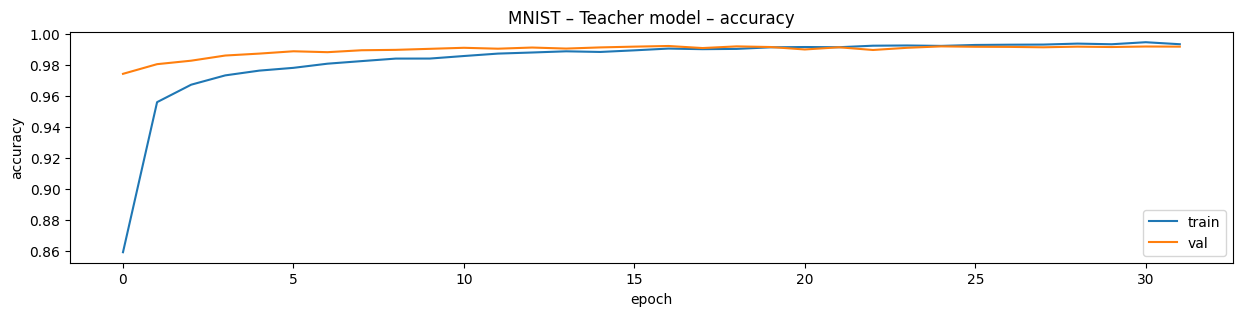

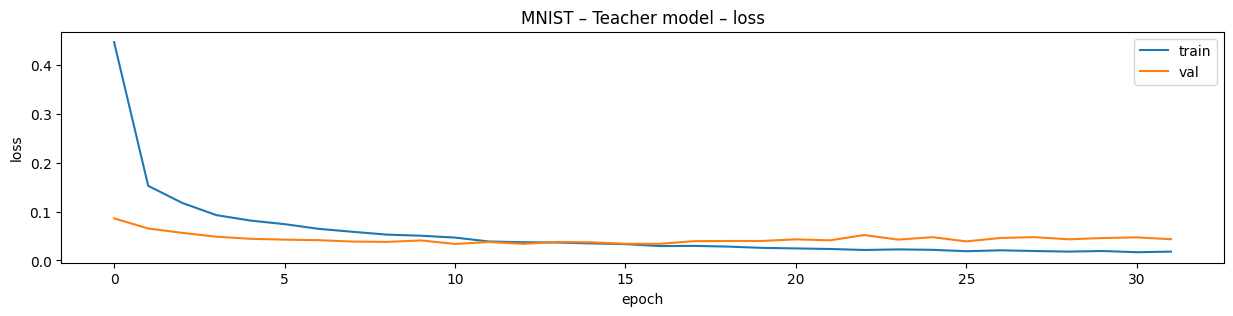

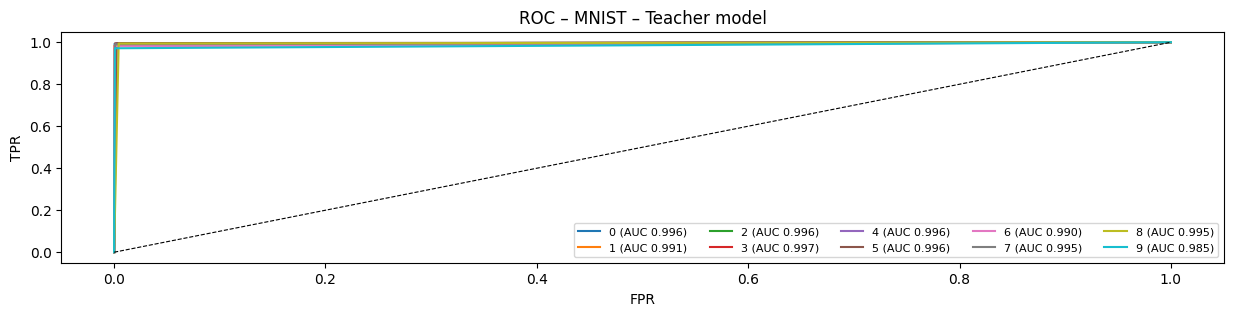

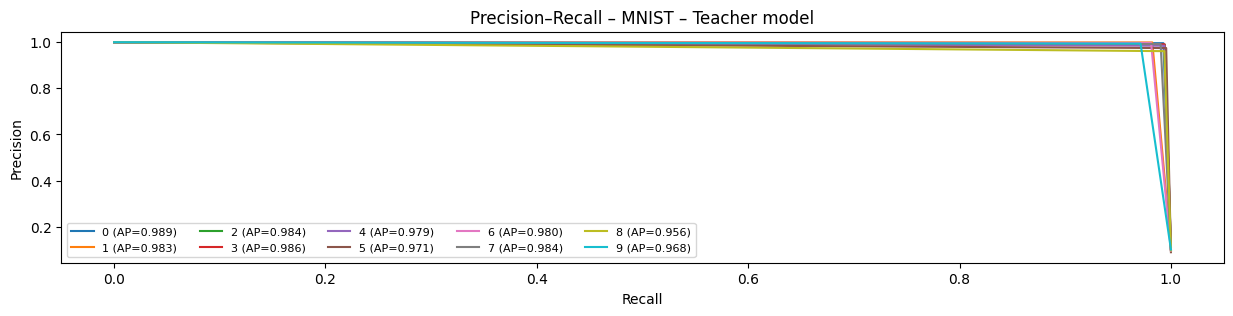

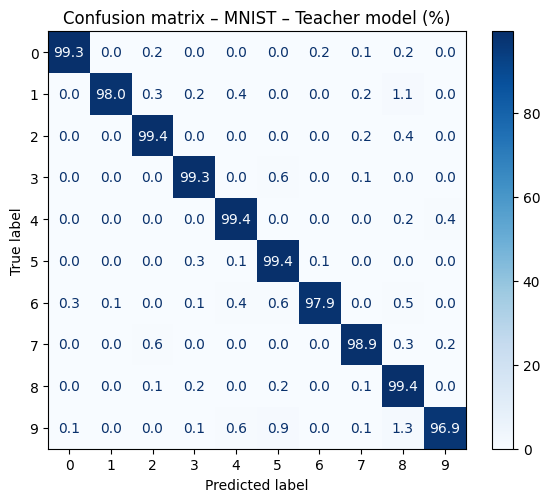

In [11]:
figs, aucs, metrics = report_classifier(
    history=history_2Dconv_mnist,         
    y_true=y_test,
    y_proba=model_2Dconv_mnist.predict(x_test, batch_size=256, verbose=0),
    class_names=[str(i) for i in range(10)],  
    model_name="MNIST – Teacher model",
    threshold=0.5,             
    save_prefix=None          
)


In [12]:
from sklearn.metrics import accuracy_score

y_pred = model_2Dconv_mnist.predict(x_test_norm)
y_pred_classes = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_classes)
print("Accuracy:", accuracy)

313/313 [==============================] - 0s 1ms/step
Accuracy: 0.9928


In [13]:
model_2Dconv_mnist.save('./models/teacher_model_2Dconv_mnist.h5')

---

### Student training

The student model is defined using quantization and pruning strategies.  

For the classification task, the number of bits was set to eight, and the target sparsity was set to 70%. 

**Qkeras** is employed to define the student model in a quantized manner. 

**For more information regarding QKeras:** Coelho, C. N., Kuusela, A., Zhuang, H., Aarrestad, T., Loncar, V., Ngadiuba, J., ... & Summers, S. (2020). _Ultra low-latency, low-area inference accelerators using heterogeneous deep quantization with QKeras and hls4ml_. arXiv preprint arXiv:2006.10159, 108.

In [14]:

# Strategy: Quantization (QKeras, 8-bit) + Pruning (TF-MOT, up to 70% sparsity)
# Pruning schedule: PolynomialDecay — starts after 2 warm-up epochs,
#                   ends 2 epochs before training finishes
# LR schedule:      ExponentialDecay with staircase steps (decays every 2000 steps)
# Callbacks:        UpdatePruningStep + ReduceLROnPlateau + EarlyStopping + ModelCheckpoint

# --- General Training Hyperparameters ---
epochs_s   = 32
batch_s    = 64
val_split  = 0.2
loss       = 'sparse_categorical_crossentropy'
metrics    = ['accuracy']
base_lr    = 1e-3

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate = base_lr,
    decay_steps           = 2000,
    decay_rate            = 0.96,
    staircase             = True
)

op = Adam(learning_rate=lr_schedule)

# --- Pruning Schedule Setup ---
num_train       = 60000     # Total MNIST training samples
warmup_epochs   = 2         # Epochs before pruning begins [lets model stabilize first]
finish_margin_ep = 2        # Pruning stops N epochs before end [allows model to recover]

# Effective training samples after validation split (60000 × 0.8 = 48000)
steps_per_epoch = math.ceil(num_train * (1 - val_split) / batch_s)  # ≈ 375 steps/epoch

begin_step = warmup_epochs                        * steps_per_epoch  # Step where pruning starts
end_step   = (epochs_s - finish_margin_ep)        * steps_per_epoch  # Step where pruning ends

# PolynomialDecay: gradually increases sparsity from 0% to 70% between begin_step and end_step
pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity = 0.0,          # No weights pruned at the start
    final_sparsity   = 0.50,         # 50% of weights zeroed out by end_step
    begin_step       = begin_step,
    end_step         = end_step,
    frequency        = steps_per_epoch   # Pruning mask updated once per epoch
)

# --- Callbacks ---
callbacks = [
    # Required: updates pruning masks at each training step based on the schedule
    tfmot.sparsity.keras.UpdatePruningStep(),

    # Halves the LR if val_accuracy doesn't improve for 2 epochs
    # min_lr=5e-5 prevents the LR from dropping too low and stalling training
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5, patience=2, verbose=1, min_lr=5e-5
    ),

    # Stops training early if val_accuracy doesn't improve for 5 epochs
    # restore_best_weights=True: reverts to the best checkpoint after stopping
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True
    ),

    # Saves the best model weights whenever val_accuracy improves
    # save_best_only=True: avoids overwriting a better checkpoint with a worse one
    tf.keras.callbacks.ModelCheckpoint(
        'mnist_pruned_best.h5', monitor='val_accuracy', save_best_only=True
    )
]

In [25]:

## Quantization strategy
kernelQ = "quantized_bits(8,4)"
biasQ = "quantized_bits(8, 4)"
activationQ = 'quantized_bits(8, 4)'

# Quantized student definition
# Input:  28×28 grayscale images, 1 channel (same as teacher)
# Body:   2 quantized convolutional blocks (QConv2D + QActivation + MaxPooling + Dropout)
#         ├─ Block 1: 2 filters  → minimal low-level feature extraction
#         └─ Block 2: 4 filters  → lightweight mid-level feature extraction
#         Spatial reduction: 28×28 → 14×14 → 7×7
# Head:   Flatten → QDense(8) + QActivation + Dropout → QDense(10) + Softmax
# Output: 10-class probability distribution

modelQ_CNN = Sequential([
    
    QConv2D(2, kernel_size=(3, 3), padding='same',
            kernel_quantizer=kernelQ, bias_quantizer=biasQ,
            kernel_initializer='lecun_uniform',
            input_shape=(28, 28, 1), name='conv1'),
    QActivation(activation=activationQ, name='act1'),
    MaxPooling2D(pool_size=(2, 2), name='pool1'),
    Dropout(0.1),
    
    QConv2D(4, kernel_size=(3, 3), padding='same',
            kernel_quantizer=kernelQ, bias_quantizer=biasQ,
            kernel_initializer='lecun_uniform',
            name='conv2'),
    QActivation(activation=activationQ, name='act2'),
    MaxPooling2D(pool_size=(2, 2), name='pool2'),
    Dropout(0.1),
    
    # Aplanado
    Flatten(name='flatten'),

    QDense(8, name='fc1',
           kernel_quantizer=kernelQ, bias_quantizer=biasQ,
           kernel_initializer='lecun_uniform'),
    QActivation(activation=activationQ, name='act_fc1'),


    QDense(10, name='output',
           kernel_quantizer=kernelQ, bias_quantizer=biasQ,
           kernel_initializer='lecun_uniform'),
    Activation('softmax', name='softmax')

], name="quantizedCNNModel")

In [26]:
modelQ_CNN.summary()

Model: "quantizedCNNModel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (QConv2D)             (None, 28, 28, 2)         20        
                                                                 
 act1 (QActivation)          (None, 28, 28, 2)         0         
                                                                 
 pool1 (MaxPooling2D)        (None, 14, 14, 2)         0         
                                                                 
 dropout_4 (Dropout)         (None, 14, 14, 2)         0         
                                                                 
 conv2 (QConv2D)             (None, 14, 14, 4)         76        
                                                                 
 act2 (QActivation)          (None, 14, 14, 4)         0         
                                                                 
 pool2 (MaxPooling2D)        (None, 7, 7, 4)     

In [27]:
import math
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from tensorflow.keras.optimizers import Adam
modelQAP = tfmot.sparsity.keras.prune_low_magnitude(modelQ_CNN,  pruning_schedule=pruning_schedule)

In [28]:
# Next, we initialize the distillation process using a custom Distiller class:
    # - teacher: the pre-trained high-capacity model.
    # - student: the smaller model that will learn to mimic the teacher.

# The Distiller class typically overrides the training loop to incorporate both soft-label loss (from the teacher's predictions) 
# and hard-label loss (from ground truth), enabling the student to learn from both sources.

distilledCNN = Distiller(student=modelQAP, teacher=model_2Dconv_mnist)

In [29]:
# Knowledge Distillation Process

# We now configure and compile the `Distiller` model to begin the knowledge distillation process.
# Key Components:

    # - optimizer: Uses the Adam optimizer with a low learning rate (1e-3) for stable training.
    # - metrics: Monitors the student's classification performance using SparseCategoricalAccuracy.
    # - student_loss_fn: The loss between the student model's predictions and the true labels.
    # - distillation_loss_fn: KL Divergence loss between the teacher and student outputs (soft targets).
    # - alpha: Balancing factor between the student loss and the distillation loss (e.g., 0.1 = mostly focus on soft targets).
    # - temperature: Softens the output probabilities of the teacher (higher = softer), allowing the student to learn richer patterns.

# This setup enables the student model to learn both from the actual labels and from the teacher's knowledge, improving efficiency and generalization

from tensorflow_model_optimization.python.core.sparsity.keras import pruning_callbacks
callbacks = [
                tf.keras.callbacks.EarlyStopping(monitor='sparse_categorical_accuracy', patience=10, verbose=1),
                tf.keras.callbacks.ReduceLROnPlateau(monitor='sparse_categorical_accuracy', factor=0.3, patience=310, verbose=1),
                pruning_callbacks.UpdatePruningStep()
                ]  

adam = Adam(0.0001)

distilledCNN.compile(
        optimizer=adam,
        metrics=[keras.metrics.SparseCategoricalAccuracy()],
        student_loss_fn=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        distillation_loss_fn=keras.losses.KLDivergence(),
        alpha=0.1, 
        temperature=10,
    )

history_distilledCNN = distilledCNN.fit(x_train_norm, y_train, validation_split=0.2, batch_size = batch_s, epochs= epochs_s, callbacks = callbacks)

Epoch 1/32


2026-04-01 16:24:07.545078: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inquantizedCNNModel/prune_low_magnitude_dropout_4/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


750/750 [==============================] - 16s 14ms/step - sparse_categorical_accuracy: 0.2367 - student_loss: 2.1175 - distillation_loss: 4.5111e-04 - val_sparse_categorical_accuracy: 0.5259 - val_student_loss: 1.7619 - lr: 1.0000e-04
Epoch 2/32
750/750 [==============================] - 9s 12ms/step - sparse_categorical_accuracy: 0.6301 - student_loss: 1.3219 - distillation_loss: 3.1169e-04 - val_sparse_categorical_accuracy: 0.7730 - val_student_loss: 0.8416 - lr: 1.0000e-04
Epoch 3/32
750/750 [==============================] - 9s 12ms/step - sparse_categorical_accuracy: 0.7696 - student_loss: 0.7801 - distillation_loss: 1.8510e-04 - val_sparse_categorical_accuracy: 0.8453 - val_student_loss: 0.5388 - lr: 1.0000e-04
Epoch 4/32
750/750 [==============================] - 9s 12ms/step - sparse_categorical_accuracy: 0.8172 - student_loss: 0.6061 - distillation_loss: 1.4337e-04 - val_sparse_categorical_accuracy: 0.8726 - val_student_loss: 0.3231 - lr: 1.0000e-04
Epoch 5/32
750/750 [======

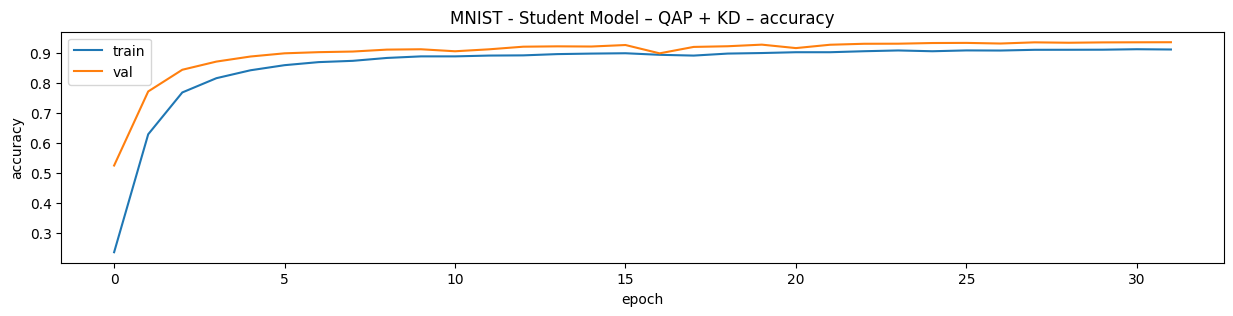

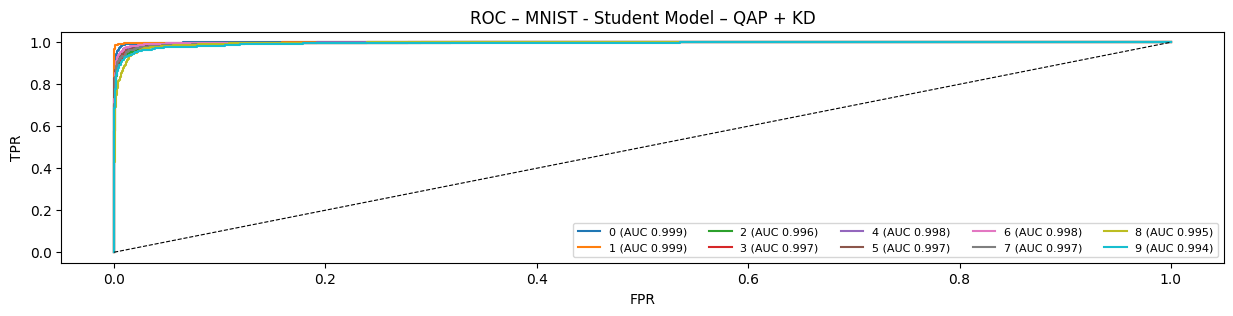

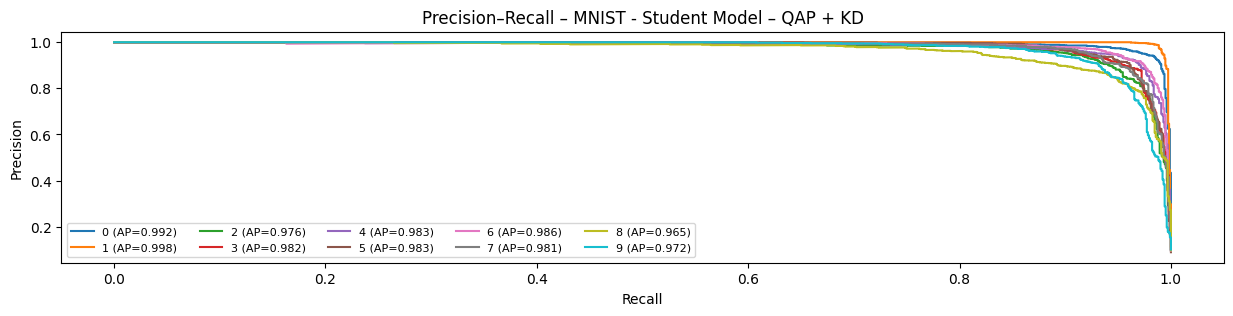

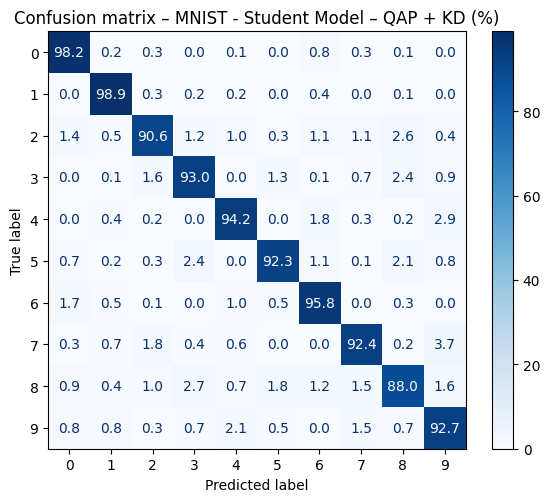

In [30]:
figs, aucs, metrics = report_classifier(
    history=history_distilledCNN,            
    y_true=y_test,
    y_proba=distilledCNN.student.predict(x_test_norm, batch_size=256, verbose=0),
    class_names=[str(i) for i in range(10)],  
    model_name="MNIST - Student Model – QAP + KD",
    threshold=0.5,             
    save_prefix=None         
)

In [21]:
# strip_pruning removes all pruning-related wrapper layers and metadata that were added during training (e.g. pruning masks, step counters).
# The result is a clean, lightweight model where pruned weights remain as zeros, reducing model complexity without affecting the learned sparsity.
distilled = strip_pruning(distilledCNN.student)

In [22]:
# Save the stripped model to disk in HDF5 (.h5) format.
# This file contains the full model architecture, weights, and optimizer state, ready for inference or deployment

distilled.save("./models/distilled-mnist.h5")

In [23]:
# Final summary (if needed)
# distilled.summary()

In [24]:
# Verify sparsity
total_params = 0
zero_params = 0

for layer in distilledCNN.student.layers:
    for w in layer.get_weights():
        total_params += w.size
        zero_params += np.sum(w == 0)

print("Sparsity total:", zero_params / total_params)


Sparsity total: 0.4931895573212259


----

With the training pipeline complete, the next notebook covers the HLS/ML workflow: from HLS4ML conversion to IP core generation.

**Next step:** Proceed to the next notebook *02.hls4ml/cnn-hls4ml.ipynb*.


---


This work was supported in part by the [AMD University Program](https://www.amd.com/en/corporate/university-program.html) 